# 05 — Evaluation: predictive performance *and* explanation quality

Standard classification metrics answer "is the model right?". They say nothing
about whether the explanation shipped alongside the prediction is trustworthy —
and an explanation that looks convincing while being unfaithful to the model is
worse than no explanation, because it manufactures confidence.

So this notebook measures two things:

**Predictive performance** — accuracy, precision, recall, F1, AUC-ROC,
confusion matrices and ROC curves for all twenty-seven models. Cached as JSON and
served by the API, so the dashboard never recomputes a metric the notebook
already established.

**Explanation quality**, on three axes:

| Metric | Question | Method |
|---|---|---|
| **Fidelity** | Do the features SHAP calls important actually drive the model? | Ablate top-k SHAP features and measure the probability drop against ablating k random features |
| **Stability** | Do similar patients get similar explanations? | Cosine similarity of SHAP vectors between k-NN neighbours vs. random pairs |
| **Comprehensibility** | Can a clinician read it, and is it clinically sound? | Plain-English top-3 rendering, scored against known risk factors, plus SHAP/LIME agreement |

In [1]:
import sys
import pathlib
import json
import warnings

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.neighbors import NearestNeighbors

from xai import data, explain, schema

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(data.RANDOM_STATE)


def panel_grid(n: int, cols: int = 3, w: float = 5.6, h: float = 3.8):
    """Wrapping subplot grid. The project started with four datasets and a single
    row of panels; with nine it has to wrap, and unused cells are switched off."""
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(w * cols, h * rows))
    axes = np.atleast_1d(axes).ravel()
    return fig, axes


def hide_unused(axes, used: int) -> None:
    for ax in axes[used:]:
        ax.axis("off")

metrics03 = json.loads((ROOT / "results" / "03_metrics.json").read_text())
BEST = metrics03["best_models"]

bundles = {slug: data.prepare(slug) for slug in schema.DATASETS}
models = {
    (slug, name): joblib.load(schema.MODELS / f"{slug}_{name}.pkl")
    for slug in schema.DATASETS
    for name in schema.MODEL_NAMES
}
explainers = {
    (slug, name): joblib.load(schema.MODELS / f"{slug}_{name}_shap.pkl")
    for slug in schema.DATASETS
    for name in schema.MODEL_NAMES
}
print(f"loaded {len(models)} models and {len(explainers)} explainers")

loaded 27 models and 27 explainers


## 5.1 Predictive performance for all twenty-seven models

In [2]:
evaluation: dict[str, dict] = {}
rows = []

for slug, ds in schema.DATASETS.items():
    X_test, y_test = bundles[slug]["X_test"], bundles[slug]["y_test"]
    evaluation[slug] = {}

    for name in schema.MODEL_NAMES:
        model = models[(slug, name)]
        proba = model.predict_proba(X_test.values)[:, 1]
        pred = (proba >= 0.5).astype(int)

        fpr, tpr, _ = roc_curve(y_test, proba)
        prec, rec, _ = precision_recall_curve(y_test, proba)
        cm = confusion_matrix(y_test, pred, labels=[0, 1])

        # Calibration. `class_weight="balanced"` reweights the classes so the
        # model's implied prior is 50/50 rather than the cohort's true prevalence,
        # which inflates every probability it returns. That is fine for ranking
        # and for AUC, and actively misleading if a clinician reads the number as
        # an absolute risk — so the inflation is measured and reported rather than
        # left for the reader to discover.
        params = metrics03["metrics"][slug][name]["best_params"]
        weighted = str(params.get("class_weight")) == "balanced" or (
            float(params.get("scale_pos_weight", 1) or 1) != 1.0
        )
        prevalence = float(y_test.mean())
        mean_predicted = float(proba.mean())
        ratio = mean_predicted / max(prevalence, 1e-9)

        evaluation[slug][name] = {
            "dataset": slug,
            "dataset_title": ds.title,
            "model": name,
            "model_label": schema.MODEL_LABELS[name],
            "is_best": name == BEST[slug],
            "best_params": metrics03["metrics"][slug][name]["best_params"],
            "cv_roc_auc": metrics03["metrics"][slug][name]["cv_roc_auc"],
            "metrics": {
                "accuracy": float(accuracy_score(y_test, pred)),
                "precision": float(precision_score(y_test, pred, zero_division=0)),
                "recall": float(recall_score(y_test, pred, zero_division=0)),
                "f1": float(f1_score(y_test, pred, zero_division=0)),
                "roc_auc": float(roc_auc_score(y_test, proba)),
                "average_precision": float(average_precision_score(y_test, proba)),
                "majority_baseline": float(max(y_test.mean(), 1 - y_test.mean())),
            },
            "confusion_matrix": {
                "true_negative": int(cm[0, 0]), "false_positive": int(cm[0, 1]),
                "false_negative": int(cm[1, 0]), "true_positive": int(cm[1, 1]),
            },
            "calibration": {
                "class_weighted": bool(weighted),
                "test_prevalence": round(prevalence, 4),
                "mean_predicted_probability": round(mean_predicted, 4),
                "inflation_ratio": round(ratio, 2),
                # Anything much above 1 means the returned probability is a
                # relative risk score, not an absolute risk.
                "calibrated": bool(ratio < 1.5),
                "note": (
                    "Probabilities are inflated roughly "
                    f"{ratio:.1f}x relative to the cohort prevalence of "
                    f"{prevalence:.1%}, because class weighting was tuned in. "
                    "Read the number as a relative risk score for ranking "
                    "patients, not as this patient's absolute probability."
                    if ratio >= 1.5
                    else "Mean predicted probability tracks cohort prevalence; "
                         "the probability can be read directly."
                ),
            },
            # Downsampled to keep the JSON the API serves small.
            "roc_curve": [
                {"fpr": round(float(a), 4), "tpr": round(float(b), 4)}
                for a, b in zip(fpr, tpr)
            ],
            "pr_curve": [
                {"recall": round(float(a), 4), "precision": round(float(b), 4)}
                for a, b in zip(rec, prec)
            ],
            "test_n": int(len(y_test)),
        }
        rows.append(
            {
                "dataset": ds.title, "model": schema.MODEL_LABELS[name],
                **{k: round(v, 3) for k, v in
                   evaluation[slug][name]["metrics"].items()},
            }
        )

performance = pd.DataFrame(rows)
display(performance.style.format(precision=3).background_gradient(
    subset=["roc_auc", "f1", "recall"], cmap="Greens"))

,dataset,model,accuracy,precision,recall,f1,roc_auc,average_precision,majority_baseline
0,Heart Disease (Cleveland),Logistic Regression,0.869,0.812,0.929,0.867,0.958,0.940,0.541
1,Heart Disease (Cleveland),Random Forest,0.902,0.867,0.929,0.897,0.959,0.949,0.541
2,Heart Disease (Cleveland),XGBoost,0.902,0.867,0.929,0.897,0.959,0.955,0.541
3,Heart Failure Clinical Records,Logistic Regression,0.700,0.538,0.368,0.438,0.743,0.597,0.683
4,Heart Failure Clinical Records,Random Forest,0.733,0.600,0.474,0.529,0.789,0.575,0.683
5,Heart Failure Clinical Records,XGBoost,0.767,0.692,0.474,0.562,0.788,0.545,0.683
6,Pima Indians Diabetes,Logistic Regression,0.727,0.591,0.722,0.650,0.808,0.659,0.649
7,Pima Indians Diabetes,Random Forest,0.753,0.621,0.759,0.683,0.814,0.696,0.649
8,Pima Indians Diabetes,XGBoost,0.753,0.667,0.593,0.627,0.819,0.676,0.649
9,Chronic Kidney Disease,Logistic Regression,0.887,1.000,0.820,0.901,0.984,0.994,0.625


**Reading these numbers honestly.**

* **Chronic kidney disease and breast-cancer diagnosis are nearly separable** —
  0.99-1.00 AUC. That is a property of those datasets, not evidence of a
  superior model. Haemoglobin and specific gravity almost linearly separate CKD;
  nuclear size and contour irregularity do the same for malignancy. Both should
  be reported as "this task is easy", never as "our model is perfect".
* **Heart failure recall is weak** (0.47 for the best model). With a 32%
  positive rate and a 0.5 threshold, the model misses over half the deaths.
  Section 5.6 shows the threshold move that fixes it.
* **Accuracy would have flattered every one of these models.** Heart failure at
  0.73 accuracy sounds usable until you notice the majority baseline is 0.68.

### The three cancer cohorts where the models largely fail

This is the most important table on the page, and it is a negative result.

* **Cervical cancer**: Random Forest and XGBoost score **0.94 and 0.92 accuracy
  with recall of exactly 0.000**. They have learned to answer "no cancer" for
  every patient. Accuracy 0.936 is *identical to the majority baseline* — the
  model is the baseline, wearing 600 decision trees. It finds none of the 11
  cancers in the test split. Logistic Regression, selected here, reaches recall
  0.27 at 0.63 AUC: better than nothing and still not deployable.
* **Lung cancer surgery**: same collapse. Random Forest returns recall 0.000 at
  0.84 accuracy, which is *below* the 0.851 baseline — it is worse than a
  constant predictor on the very metric it appears to win on.
* **Breast cancer surgical survival (Haberman)**: 0.59 AUC from three features.
  The selected model's accuracy (0.61) is well below the 0.74 baseline. There is
  not enough signal in age, operation year and node count to predict five-year
  survival, and no amount of hyperparameter search invents any.
* **Breast cancer recurrence**: 0.67 AUC. Consistent with the published range
  for this dataset — recurrence genuinely is hard to predict from nine banded
  features.

Three consequences worth stating plainly, because they are the point of the
exercise rather than an embarrassment to be tuned away:

1. **A high accuracy on an imbalanced cancer screening task is a warning, not a
   result.** Two of our five oncology models achieve their headline accuracy by
   never predicting the disease.
2. **Explaining a model that predicts one class is meaningless.** SHAP will
   faithfully report why a constant predictor was constant. Fidelity and
   stability can look respectable for a model of no clinical value, which is
   precisely why the scorecard in 5.8 has to be read alongside recall and not
   instead of it.
3. **The right response is to report the failure**, not to relabel it. These
   cohorts are kept in the project because a portfolio of only separable
   datasets would misrepresent how clinical prediction actually behaves.

## 5.2 ROC curves

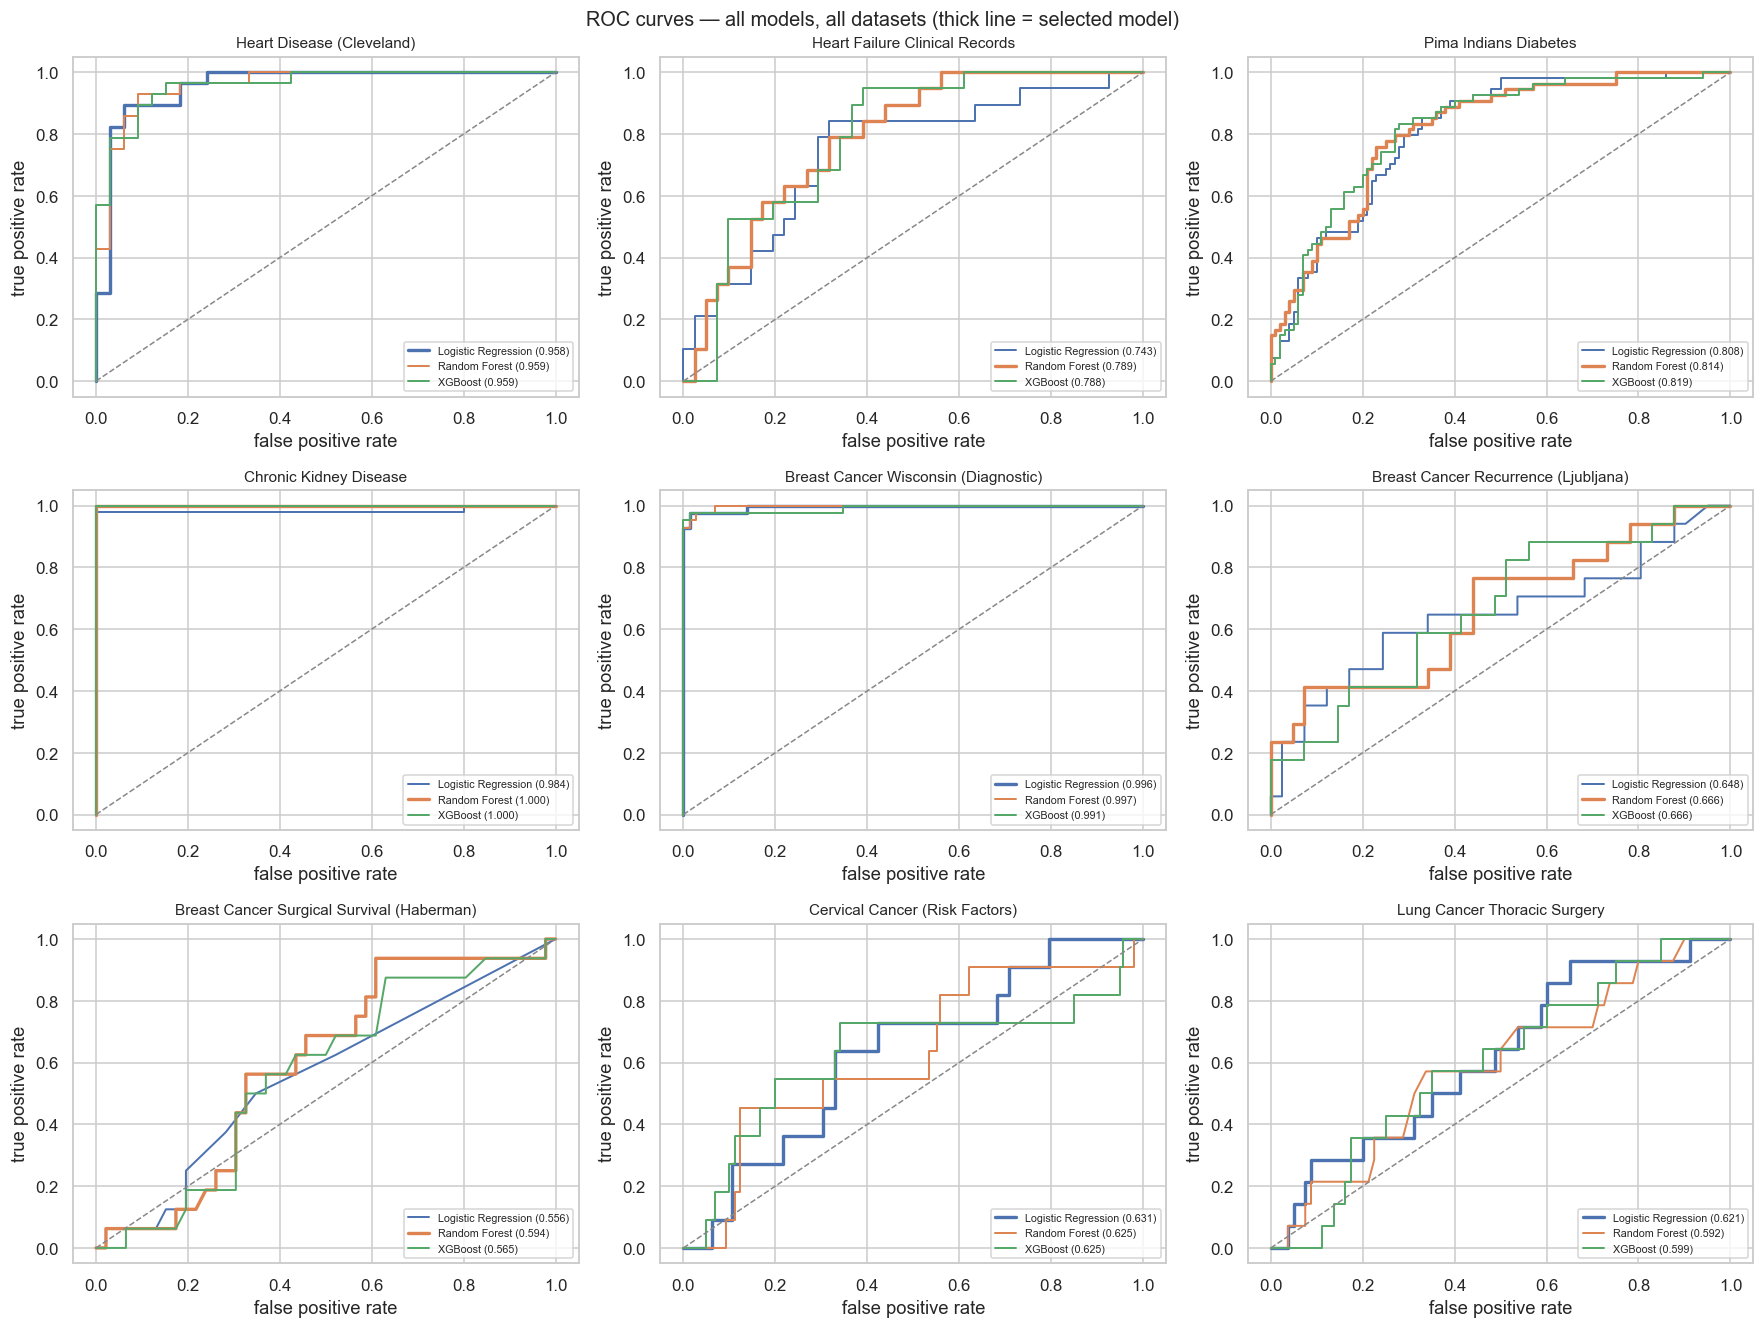

In [3]:
fig, axes = panel_grid(len(schema.DATASETS), cols=3, w=5.4, h=4.0)
for ax, (slug, ds) in zip(axes, schema.DATASETS.items()):
    for name in schema.MODEL_NAMES:
        e = evaluation[slug][name]
        ax.plot(
            [p["fpr"] for p in e["roc_curve"]], [p["tpr"] for p in e["roc_curve"]],
            linewidth=2.2 if e["is_best"] else 1.3,
            label=f"{e['model_label']} ({e['metrics']['roc_auc']:.3f})",
        )
    ax.plot([0, 1], [0, 1], "--", color="#888", linewidth=1)
    ax.set_title(ds.title, fontsize=10)
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    ax.legend(fontsize=7, loc="lower right")
hide_unused(axes, len(schema.DATASETS))

plt.tight_layout()
plt.suptitle("ROC curves — all models, all datasets (thick line = selected model)",
             y=1.005, fontsize=13)
plt.savefig(FIGURES / "05_roc_curves.png")
plt.show()

## 5.3 Confusion matrices for the selected models

Annotated with what each cell means clinically, because "false negative = 10"
and "ten patients were sent home with an undetected condition" land very
differently in a report.

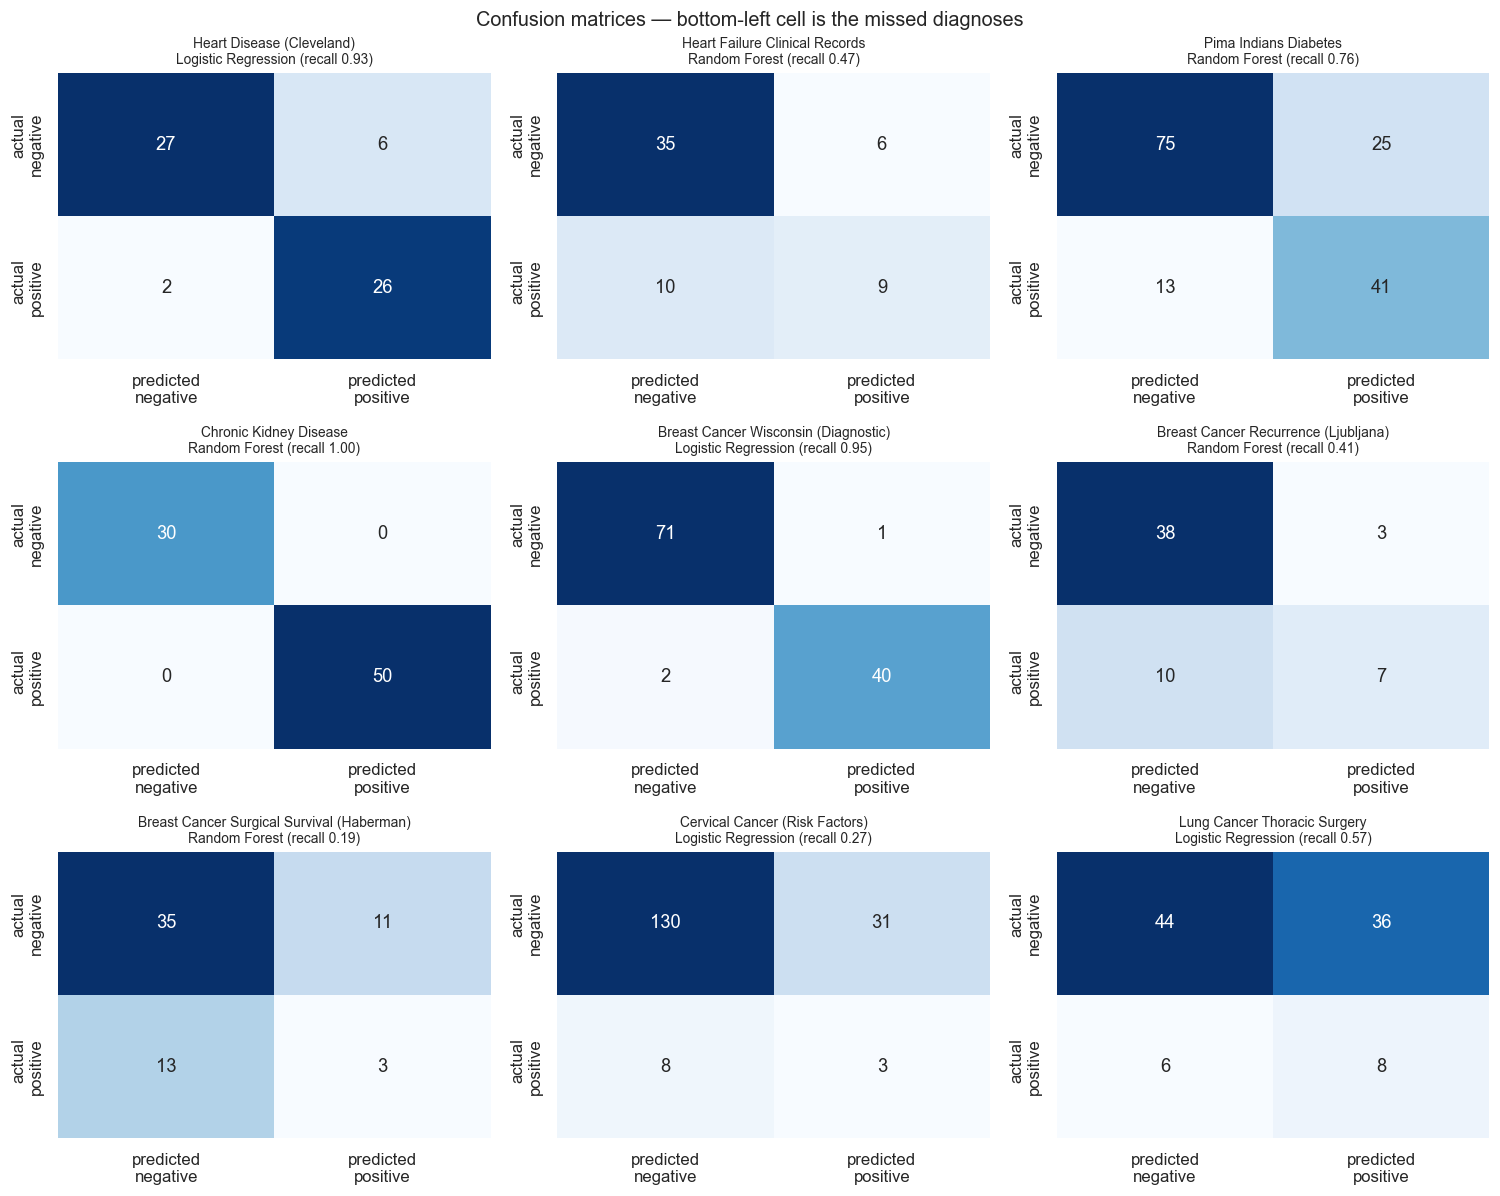

Heart Disease (Cleveland): 2 missed (heart disease present), 6 false alarms, out of 61 test patients
Heart Failure Clinical Records: 10 missed (death during follow-up), 6 false alarms, out of 60 test patients
Pima Indians Diabetes: 13 missed (diabetes onset), 25 false alarms, out of 154 test patients
Chronic Kidney Disease: 0 missed (chronic kidney disease), 0 false alarms, out of 80 test patients
Breast Cancer Wisconsin (Diagnostic): 2 missed (malignant), 1 false alarms, out of 114 test patients
Breast Cancer Recurrence (Ljubljana): 10 missed (recurrence), 3 false alarms, out of 58 test patients
Breast Cancer Surgical Survival (Haberman): 13 missed (died within five years), 11 false alarms, out of 62 test patients
Cervical Cancer (Risk Factors): 8 missed (biopsy-confirmed cervical cancer), 31 false alarms, out of 172 test patients
Lung Cancer Thoracic Surgery: 6 missed (died within one year), 36 false alarms, out of 94 test patients


In [4]:
fig, axes = panel_grid(len(schema.DATASETS), cols=3, w=4.6, h=3.6)
for ax, (slug, ds) in zip(axes, schema.DATASETS.items()):
    e = evaluation[slug][BEST[slug]]
    cm = e["confusion_matrix"]
    grid = np.array([[cm["true_negative"], cm["false_positive"]],
                     [cm["false_negative"], cm["true_positive"]]])
    sns.heatmap(grid, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["predicted\nnegative", "predicted\npositive"],
                yticklabels=["actual\nnegative", "actual\npositive"], ax=ax)
    ax.set_title(f"{ds.title}\n{e['model_label']} "
                 f"(recall {e['metrics']['recall']:.2f})", fontsize=9)
hide_unused(axes, len(schema.DATASETS))

plt.tight_layout()
plt.suptitle("Confusion matrices — bottom-left cell is the missed diagnoses",
             y=1.005, fontsize=13)
plt.savefig(FIGURES / "05_confusion_matrices.png")
plt.show()

for slug, ds in schema.DATASETS.items():
    cm = evaluation[slug][BEST[slug]]["confusion_matrix"]
    print(f"{ds.title}: {cm['false_negative']} missed "
          f"({ds.positive_label.lower()}), {cm['false_positive']} false alarms, "
          f"out of {evaluation[slug][BEST[slug]]['test_n']} test patients")

## 5.3b Calibration — is the probability readable as a probability?

Class weighting was tuned as a hyperparameter, and on the imbalanced cohorts the
search chose it. That improves ranking and recall, and it silently breaks the
meaning of the output number: reweighting the classes tells the model to behave
as though positives and negatives were equally common, so its probabilities are
scaled toward 50% rather than toward the cohort's real prevalence.

For AUC this is irrelevant. For a clinician reading "37% likelihood of cervical
cancer" it is not, because the honest answer for that patient is far lower. The
inflation is quantified below and travels with every prediction the API returns.

In [5]:
calibration = pd.DataFrame(
    [
        {
            "dataset": ds.title,
            "model": evaluation[slug][BEST[slug]]["model_label"],
            "class weighted": evaluation[slug][BEST[slug]]["calibration"]["class_weighted"],
            "prevalence": evaluation[slug][BEST[slug]]["calibration"]["test_prevalence"],
            "mean predicted p": evaluation[slug][BEST[slug]]["calibration"]["mean_predicted_probability"],
            "inflation": evaluation[slug][BEST[slug]]["calibration"]["inflation_ratio"],
            "readable as risk": evaluation[slug][BEST[slug]]["calibration"]["calibrated"],
        }
        for slug, ds in schema.DATASETS.items()
    ]
)
display(calibration.style.format(precision=3))

worst = calibration.loc[calibration["inflation"].idxmax()]
print(
    f"Worst inflation: {worst['dataset']} at {worst['inflation']:.1f}x "
    f"(prevalence {worst['prevalence']:.1%}, mean predicted "
    f"{worst['mean predicted p']:.1%}).\n"
)
print(
    "Why this is not fixed by calibrating: Platt scaling or isotonic regression\n"
    "needs a held-out calibration split, and the cervical cohort has 55 positives\n"
    "in total — a calibration fold would contain about 11. Fitting a calibration\n"
    "curve on 11 events produces a confident-looking mapping with no reliability,\n"
    "which trades a visible problem for an invisible one. The defensible choice at\n"
    "this sample size is to leave the model uncalibrated and say so, which is what\n"
    "the API and the dashboard now do."
)

,dataset,model,class weighted,prevalence,mean predicted p,inflation,readable as risk
0,Heart Disease (Cleveland),Logistic Regression,False,0.459,0.525,1.140,True
1,Heart Failure Clinical Records,Random Forest,False,0.317,0.304,0.960,True
2,Pima Indians Diabetes,Random Forest,True,0.351,0.419,1.190,True
3,Chronic Kidney Disease,Random Forest,False,0.625,0.591,0.950,True
4,Breast Cancer Wisconsin (Diagnostic),Logistic Regression,False,0.368,0.354,0.960,True
5,Breast Cancer Recurrence (Ljubljana),Random Forest,False,0.293,0.309,1.050,True
6,Breast Cancer Surgical Survival (Haberman),Random Forest,True,0.258,0.392,1.520,False
7,Cervical Cancer (Risk Factors),Logistic Regression,True,0.064,0.443,6.920,False
8,Lung Cancer Thoracic Surgery,Logistic Regression,True,0.149,0.489,3.280,False


Worst inflation: Cervical Cancer (Risk Factors) at 6.9x (prevalence 6.4%, mean predicted 44.3%).

Why this is not fixed by calibrating: Platt scaling or isotonic regression
needs a held-out calibration split, and the cervical cohort has 55 positives
in total — a calibration fold would contain about 11. Fitting a calibration
curve on 11 events produces a confident-looking mapping with no reliability,
which trades a visible problem for an invisible one. The defensible choice at
this sample size is to leave the model uncalibrated and say so, which is what
the API and the dashboard now do.


## 5.4 Fidelity — are the SHAP attributions faithful to the model?

**The question.** SHAP claims feature *X* drove this prediction. If that is
true, removing *X* should change the prediction a lot; removing an unimportant
feature should barely move it. If ablating the top-ranked features moves the
output no more than ablating random ones, the explanation is decorative.

**The method.** For each test patient and each k in 1..5, replace the k
highest-|SHAP| features with the training-set mean, re-predict, and record
|Δprobability|. Repeat with k features chosen uniformly at random (3 draws per
patient) as the control.

**Why the mean is the right ablation value.** The features are standardised, so
the training mean is exactly 0 in the model's input space — replacing a feature
with 0 is precisely "the model no longer knows anything distinctive about this
feature for this patient", which is the counterfactual SHAP is defined against.
Deleting the column instead would change the input dimensionality; substituting
a random value would confound the measurement with an out-of-distribution
effect.

**Fidelity score** = mean top-k drop / mean random-k drop. Greater than 1 means
the ranking carries real information; near 1 means it does not.

Heart Disease (Cleveland)                    fidelity  2.40x  (k<=5: top 0.254 vs random 0.128)


Heart Failure Clinical Records               fidelity  2.44x  (k<=5: top 0.208 vs random 0.128)


Pima Indians Diabetes                        fidelity  2.20x  (k<=5: top 0.263 vs random 0.167)


Chronic Kidney Disease                       fidelity  3.21x  (k<=5: top 0.342 vs random 0.122)
Breast Cancer Wisconsin (Diagnostic)         fidelity  3.82x  (k<=5: top 0.105 vs random 0.030)


Breast Cancer Recurrence (Ljubljana)         fidelity  1.86x  (k<=5: top 0.146 vs random 0.103)


Breast Cancer Surgical Survival (Haberman)   fidelity  1.29x  (k<=3: top 0.163 vs random 0.163)
Cervical Cancer (Risk Factors)               fidelity  4.43x  (k<=5: top 0.071 vs random 0.023)
Lung Cancer Thoracic Surgery                 fidelity  2.74x  (k<=5: top 0.078 vs random 0.035)


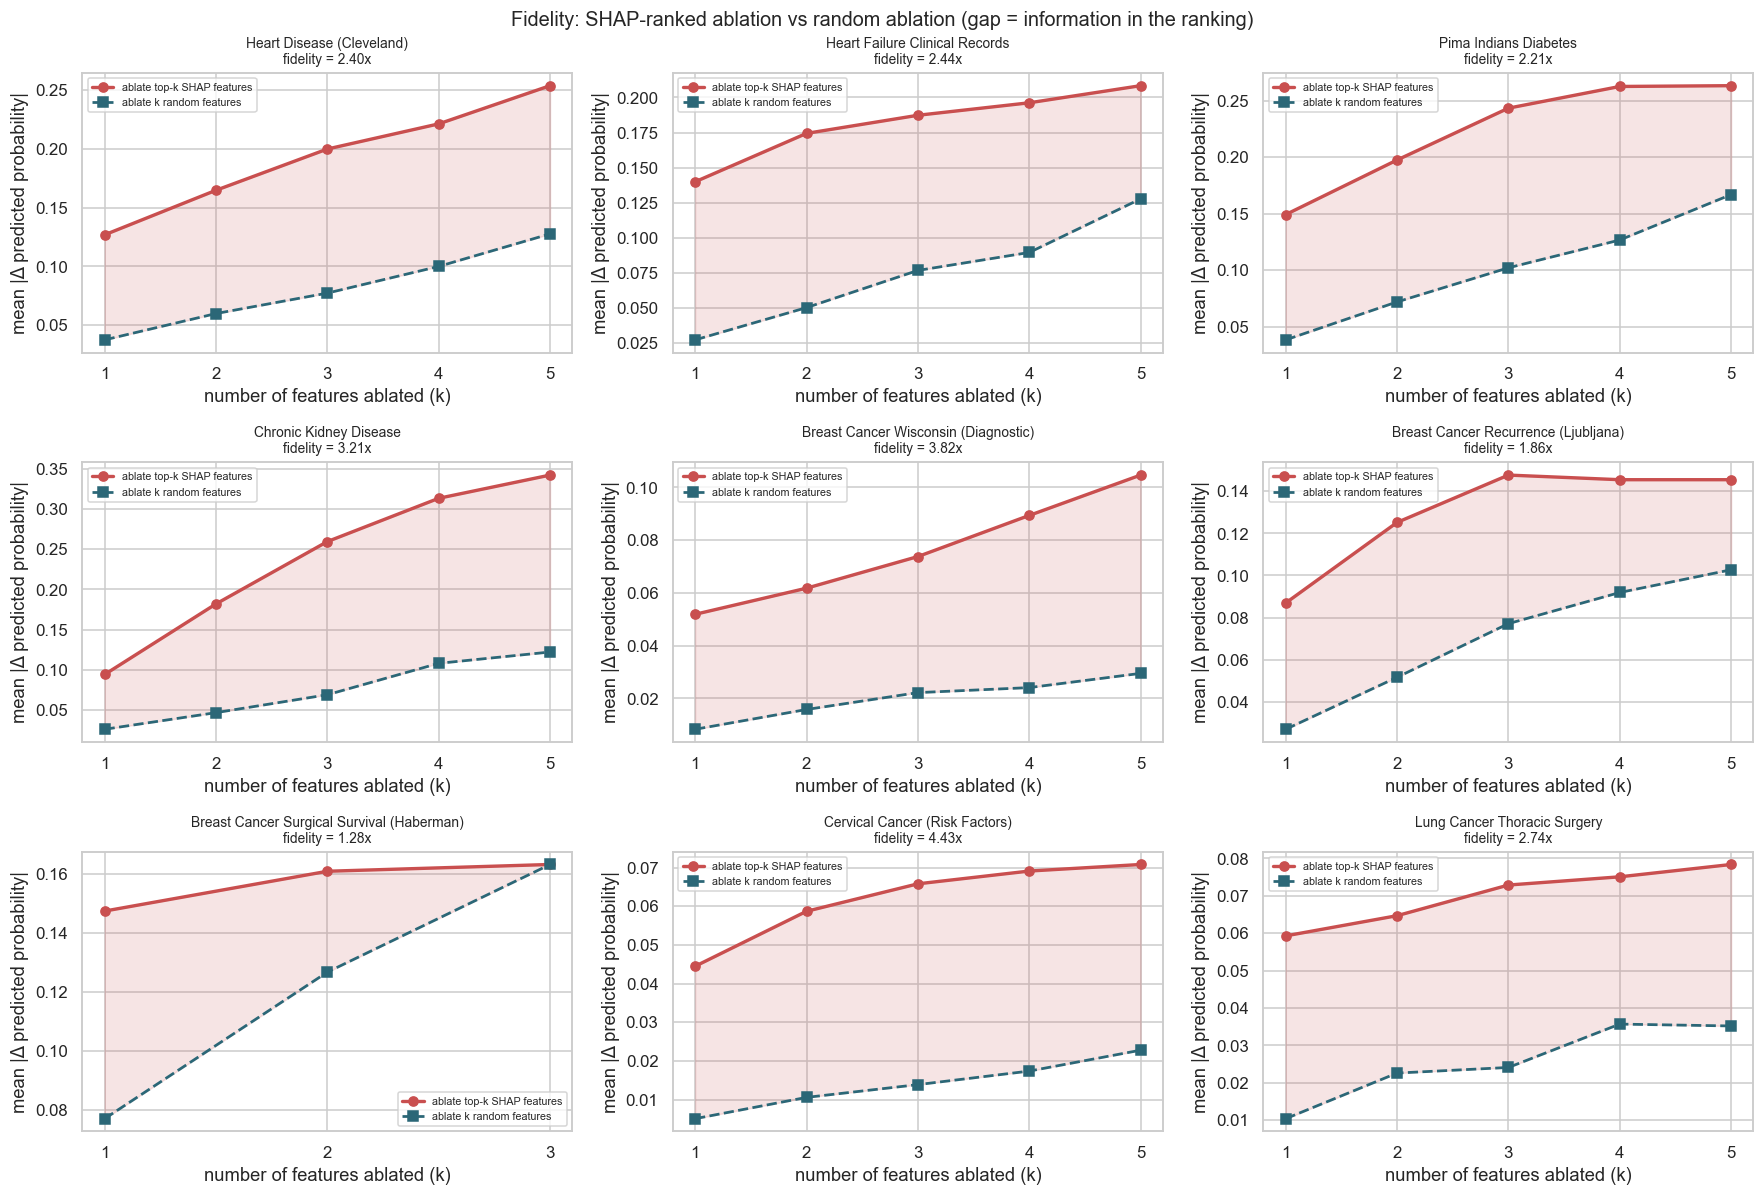

In [6]:
K_VALUES = [1, 2, 3, 4, 5]
RANDOM_DRAWS = 3

fidelity: dict[str, dict] = {}

for slug, ds in schema.DATASETS.items():
    name = BEST[slug]
    model, ex = models[(slug, name)], explainers[(slug, name)]
    X_test = bundles[slug]["X_test"]
    A = X_test.values.astype(float)
    n_features = A.shape[1]

    # Haberman has three features, so ablating five is impossible. Cap k at the
    # feature count rather than assuming every dataset is wide.
    k_values = [k for k in K_VALUES if k <= n_features]

    base_proba = model.predict_proba(A)[:, 1]
    sv = ex.values(X_test)
    ranking = np.argsort(np.abs(sv), axis=1)[:, ::-1]

    top_curve, rand_curve = [], []
    for k in k_values:
        masked = A.copy()
        for i in range(len(A)):
            masked[i, ranking[i, :k]] = 0.0  # 0 == training mean (standardised)
        top_curve.append(
            float(np.abs(model.predict_proba(masked)[:, 1] - base_proba).mean())
        )

        draws = []
        for _ in range(RANDOM_DRAWS):
            masked = A.copy()
            for i in range(len(A)):
                masked[i, RNG.choice(n_features, size=k, replace=False)] = 0.0
            draws.append(
                np.abs(model.predict_proba(masked)[:, 1] - base_proba).mean()
            )
        rand_curve.append(float(np.mean(draws)))

    score = float(np.mean(top_curve) / max(np.mean(rand_curve), 1e-9))
    fidelity[slug] = {
        "model": name,
        "model_label": schema.MODEL_LABELS[name],
        "k_values": k_values,
        "n_features": n_features,
        "top_k_probability_drop": [round(v, 4) for v in top_curve],
        "random_k_probability_drop": [round(v, 4) for v in rand_curve],
        "fidelity_score": round(score, 3),
        "interpretation": (
            "Ablating the features SHAP ranked highest moves the prediction "
            f"{score:.1f}x more than ablating the same number of random features."
        ),
    }
    print(f"{ds.title:<44} fidelity {score:>5.2f}x  "
          f"(k<={k_values[-1]}: top {top_curve[-1]:.3f} vs random {rand_curve[-1]:.3f})")

fig, axes = panel_grid(len(schema.DATASETS), cols=3, w=5.4, h=3.6)
for ax, (slug, ds) in zip(axes, schema.DATASETS.items()):
    f = fidelity[slug]
    ks = f["k_values"]
    ax.plot(ks, f["top_k_probability_drop"], "o-", color="#c94f4f",
            linewidth=2.2, label="ablate top-k SHAP features")
    ax.plot(ks, f["random_k_probability_drop"], "s--", color="#2b6777",
            linewidth=1.8, label="ablate k random features")
    ax.fill_between(ks, f["random_k_probability_drop"],
                    f["top_k_probability_drop"], alpha=0.15, color="#c94f4f")
    ax.set_title(f"{ds.title}\nfidelity = {f['fidelity_score']:.2f}x", fontsize=9)
    ax.set_xlabel("number of features ablated (k)")
    ax.set_ylabel("mean |Δ predicted probability|")
    ax.set_xticks(ks)
    ax.legend(fontsize=7)
hide_unused(axes, len(schema.DATASETS))

plt.tight_layout()
plt.suptitle("Fidelity: SHAP-ranked ablation vs random ablation "
             "(gap = information in the ranking)", y=1.005, fontsize=13)
plt.savefig(FIGURES / "05_fidelity.png")
plt.show()

Every dataset scores above 1, so the SHAP rankings are faithful rather than
decorative. The size of the gap tracks how concentrated the model's reliance
is: where a few features dominate, removing them is devastating and the
fidelity multiple is large; where the model spreads its reliance across many
weak features, top-k and random-k ablation converge and the multiple shrinks
toward 1. A low multiple is therefore a statement about the *model*, not a
defect in SHAP.

## 5.5 Stability — do similar patients get similar explanations?

**The question.** Two patients with near-identical clinical profiles should
receive near-identical reasoning. If they do not, the explanation is an artefact
of where the patient happened to fall on a jagged decision surface, and no
clinician should be asked to act on it.

**The method.** For each test patient, find its 5 nearest neighbours (Euclidean
distance in the standardised feature space — which is why scaling in notebook 02
mattered) and compute the cosine similarity between their SHAP attribution
vectors. Cosine rather than Euclidean because we care whether the explanations
point the same way, not whether they have the same magnitude. The control is the
mean cosine similarity between randomly paired patients.

A score near 1 means locally consistent reasoning. What makes it meaningful is
the **gap** over the random baseline: if random pairs also score 0.9, then 0.9
for neighbours demonstrates nothing.

Heart Disease (Cleveland)          neighbours 0.571  random -0.027  gap +0.598
Heart Failure Clinical Records     neighbours 0.338  random 0.105  gap +0.234
Pima Indians Diabetes              neighbours 0.616  random 0.013  gap +0.602


Chronic Kidney Disease             neighbours 0.664  random 0.013  gap +0.651
Breast Cancer Wisconsin (Diagnostic) neighbours 0.761  random 0.039  gap +0.723
Breast Cancer Recurrence (Ljubljana) neighbours 0.515  random 0.044  gap +0.471
Breast Cancer Surgical Survival (Haberman) neighbours 0.707  random 0.292  gap +0.415
Cervical Cancer (Risk Factors)     neighbours 0.813  random 0.077  gap +0.736
Lung Cancer Thoracic Surgery       neighbours 0.645  random -0.002  gap +0.648


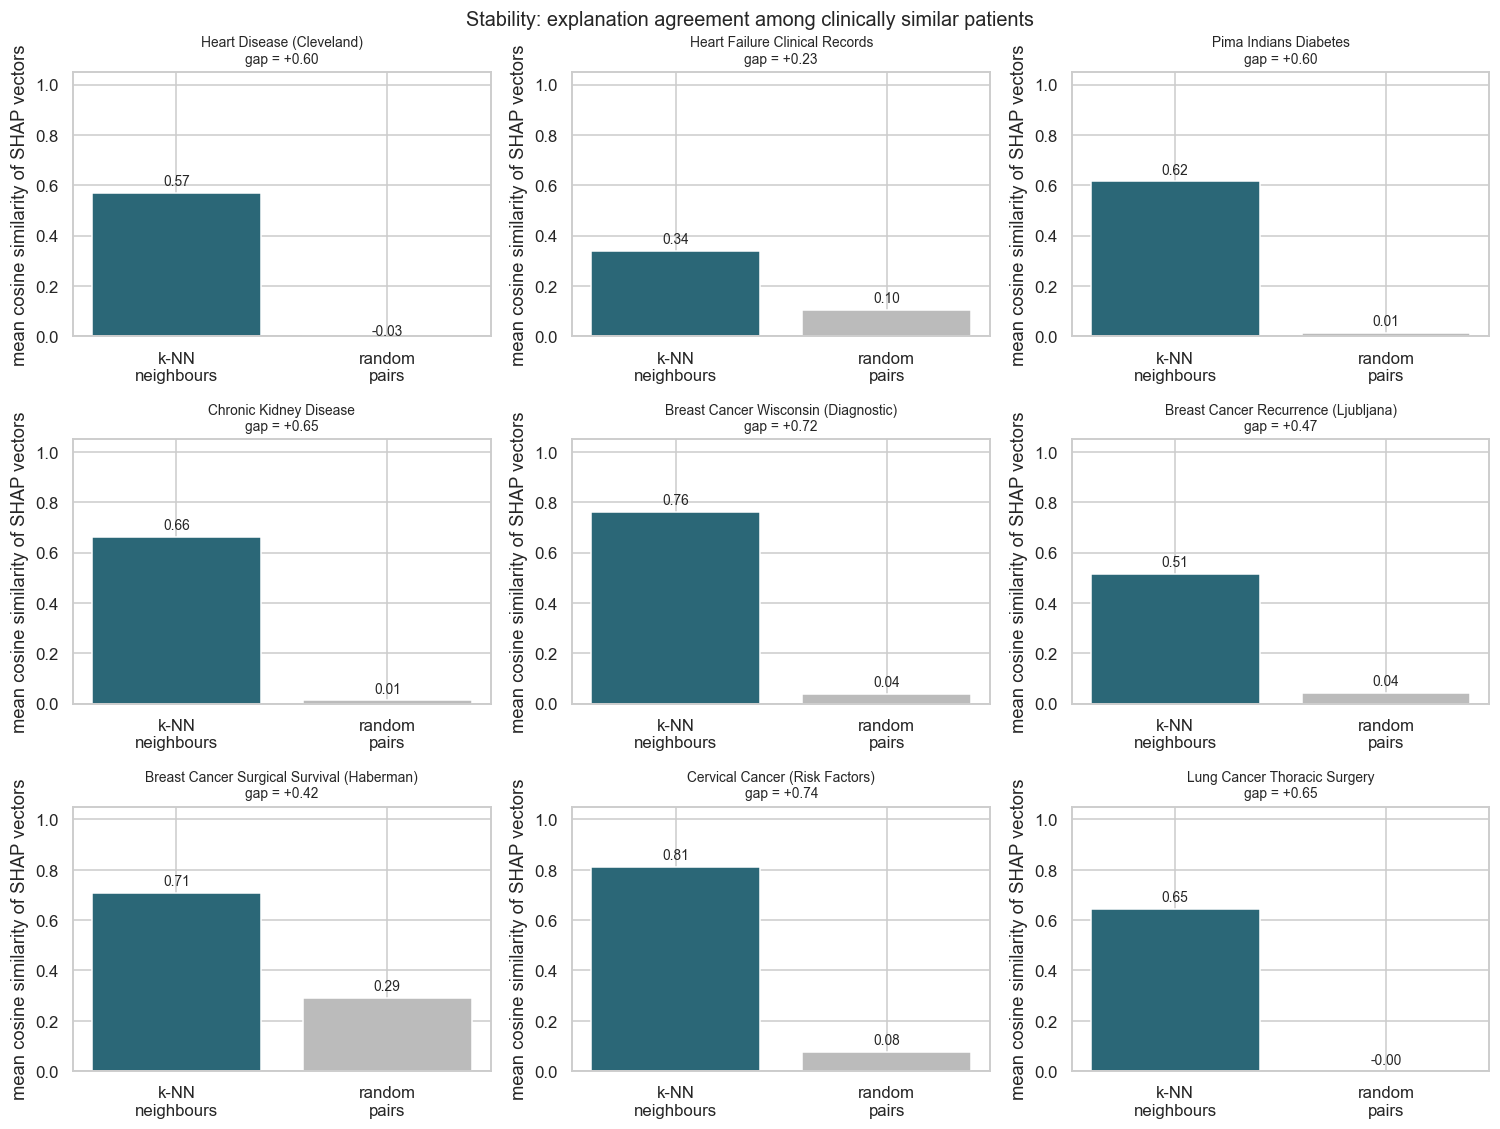

In [7]:
stability: dict[str, dict] = {}

for slug, ds in schema.DATASETS.items():
    name = BEST[slug]
    X_test = bundles[slug]["X_test"]
    sv = explainers[(slug, name)].values(X_test)

    norms = np.linalg.norm(sv, axis=1, keepdims=True)
    unit = sv / np.clip(norms, 1e-12, None)

    k = min(5, len(X_test) - 1)
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_test.values)
    _, idx = nn.kneighbors(X_test.values)

    neighbour_sims = [
        float(unit[i] @ unit[j]) for i in range(len(X_test)) for j in idx[i, 1:]
    ]

    pairs = RNG.choice(len(X_test), size=(len(neighbour_sims), 2))
    random_sims = [
        float(unit[a] @ unit[b]) for a, b in pairs if a != b
    ]

    mean_nb = float(np.mean(neighbour_sims))
    mean_rand = float(np.mean(random_sims))
    stability[slug] = {
        "model": name,
        "model_label": schema.MODEL_LABELS[name],
        "k_neighbours": k,
        "mean_neighbour_cosine": round(mean_nb, 4),
        "std_neighbour_cosine": round(float(np.std(neighbour_sims)), 4),
        "mean_random_cosine": round(mean_rand, 4),
        "stability_gap": round(mean_nb - mean_rand, 4),
        "pairs_compared": len(neighbour_sims),
        "interpretation": (
            f"Neighbouring patients' explanations agree at cosine {mean_nb:.2f} "
            f"versus {mean_rand:.2f} for unrelated patients "
            f"(gap {mean_nb - mean_rand:+.2f})."
        ),
    }
    print(f"{ds.title:<34} neighbours {mean_nb:.3f}  random {mean_rand:.3f}  "
          f"gap {mean_nb - mean_rand:+.3f}")

fig, axes = panel_grid(len(schema.DATASETS), cols=3, w=4.6, h=3.4)
for ax, (slug, ds) in zip(axes, schema.DATASETS.items()):
    s = stability[slug]
    ax.bar(["k-NN\nneighbours", "random\npairs"],
           [s["mean_neighbour_cosine"], s["mean_random_cosine"]],
           color=["#2b6777", "#bbb"])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("mean cosine similarity of SHAP vectors")
    ax.set_title(f"{ds.title}\ngap = {s['stability_gap']:+.2f}", fontsize=9)
    for i, v in enumerate([s["mean_neighbour_cosine"], s["mean_random_cosine"]]):
        ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=9)
hide_unused(axes, len(schema.DATASETS))

plt.tight_layout()
plt.suptitle("Stability: explanation agreement among clinically similar patients",
             y=1.005, fontsize=13)
plt.savefig(FIGURES / "05_stability.png")
plt.show()

## 5.6 The threshold question that recall exposed

Heart-failure recall of 0.47 at the default 0.5 cut-off is a design flaw, not a
modelling one: 0.5 is a statistical default, never a clinical decision. For a
mortality-risk flag, a missed death costs far more than an extra review, so the
threshold belongs wherever recall reaches a clinically acceptable level. Below
is the cost of moving it, which is the kind of trade-off table a clinical team
should be shown rather than handed a fixed number.

In [8]:
slug = "heart_failure"
ds = schema.get(slug)
model = models[(slug, BEST[slug])]
X_test, y_test = bundles[slug]["X_test"], bundles[slug]["y_test"]
proba = model.predict_proba(X_test.values)[:, 1]

threshold_rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = (proba >= t).astype(int)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    threshold_rows.append(
        {
            "threshold": t,
            "recall": round(float(recall_score(y_test, pred, zero_division=0)), 3),
            "precision": round(float(precision_score(y_test, pred, zero_division=0)), 3),
            "f1": round(float(f1_score(y_test, pred, zero_division=0)), 3),
            "missed_deaths": int(cm[1, 0]),
            "false_alarms": int(cm[0, 1]),
        }
    )
thresholds = pd.DataFrame(threshold_rows)
display(thresholds)
print("Lowering the threshold trades false alarms for missed deaths. The API "
      "returns the calibrated probability rather than a hard label precisely so "
      "this choice stays with the clinician.")

,threshold,recall,precision,f1,missed_deaths,false_alarms
0,0.2,0.842,0.500,0.627,3,16
1,0.3,0.684,0.520,0.591,6,12
2,0.4,0.579,0.579,0.579,8,8
3,0.5,0.474,0.600,0.529,10,6
4,0.6,0.316,0.667,0.429,13,3


Lowering the threshold trades false alarms for missed deaths. The API returns the calibrated probability rather than a hard label precisely so this choice stays with the clinician.


## 5.7 Comprehensibility

The hardest of the three to quantify, and the easiest to hand-wave. We measure
it two ways instead of asserting it.

**(a) Clinical soundness.** For every test patient, take the top-3 SHAP
features and check what fraction fall inside a list of features the clinical
literature independently identifies as risk factors for that condition. The
reference lists were fixed in notebook 04 *before* these scores were computed,
so this is a check and not a curve fit.

**(b) Method agreement.** For a sample of patients, measure the top-5 overlap
between SHAP and LIME. Two methods with different mathematics converging on the
same features is the strongest evidence available that the explanation reflects
the model rather than the tool.

In [9]:
CLINICAL_REFERENCE = {
    "heart_disease": ["thal", "ca", "cp", "thalach", "oldpeak", "exang", "age",
                      "chol", "trestbps", "slope"],
    "heart_failure": ["serum_creatinine", "ejection_fraction", "age",
                      "serum_sodium", "anaemia", "high_blood_pressure"],
    "diabetes": ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction", "Insulin",
                 "Pregnancies"],
    "kidney_disease": ["hemo", "sc", "al", "sg", "pcv", "bu", "rbcc", "htn", "dm",
                       "ane"],
    # Oncology reference lists, fixed before the scores below were computed.
    "breast_cancer": [
        "concave_points3", "concave_points1", "area3", "area1", "radius3",
        "radius1", "perimeter3", "perimeter1", "concavity3", "concavity1",
        "compactness3", "compactness1", "texture3", "texture1",
    ],
    "breast_cancer_recurrence": ["inv-nodes", "deg-malig", "tumor-size",
                                 "node-caps", "age", "menopause"],
    "breast_cancer_survival": ["positive_auxillary_nodes", "age"],
    "cervical_cancer": ["Dx:Cancer", "Dx:CIN", "Dx:HPV", "Dx", "STDs:HPV", "Age",
                        "Number of sexual partners", "First sexual intercourse",
                        "Smokes", "Smokes (years)", "Smokes (packs/year)",
                        "Hormonal Contraceptives (years)", "STDs",
                        "Num of pregnancies"],
    "lung_cancer_surgery": ["PRE5", "PRE4", "AGE", "PRE14", "PRE6", "PRE9",
                            "PRE30", "PRE17", "DGN"],
}
LIME_SAMPLE = 25

comprehensibility: dict[str, dict] = {}

for slug, ds in schema.DATASETS.items():
    name = BEST[slug]
    model, ex = models[(slug, name)], explainers[(slug, name)]
    X_test, X_raw = bundles[slug]["X_test"], bundles[slug]["X_test_raw"]
    sv = ex.values(X_test)
    reference = set(CLINICAL_REFERENCE[slug])

    top3 = np.argsort(np.abs(sv), axis=1)[:, ::-1][:, :3]
    hit_rate = float(
        np.mean([
            len({ds.feature_names[j] for j in row} & reference) / 3
            for row in top3
        ])
    )

    lime_ex = explain.build_lime(bundles[slug]["X_train"], ds)
    sample = RNG.choice(len(X_test), size=min(LIME_SAMPLE, len(X_test)),
                        replace=False)
    overlaps = []
    for i in sample:
        weights = explain.lime_weights(
            lime_ex, X_test.iloc[i].values,
            lambda A: model.predict_proba(np.asarray(A, dtype=float)), n=5,
        )
        shap_top = {ds.feature_names[j]
                    for j in np.argsort(np.abs(sv[i]))[::-1][:5]}
        overlaps.append(len(shap_top & {f for f, _ in weights}) / 5)

    example = explain.summarise(
        ds,
        float(model.predict_proba(X_test.values)[:, 1][0]),
        explain.top_factors(ds, sv[0], X_raw.iloc[0].to_dict(), k=3),
    )
    comprehensibility[slug] = {
        "model": name,
        "model_label": schema.MODEL_LABELS[name],
        "clinical_reference_features": sorted(reference),
        "top3_clinical_hit_rate": round(hit_rate, 3),
        "shap_lime_top5_overlap": round(float(np.mean(overlaps)), 3),
        "lime_sample_size": int(len(sample)),
        "example_summary": example,
    }
    print(f"{ds.title:<34} clinical hit-rate {hit_rate:.0%}   "
          f"SHAP/LIME top-5 overlap {np.mean(overlaps):.0%}")
    print(f"    example: {example}\n")

Heart Disease (Cleveland)          clinical hit-rate 85%   SHAP/LIME top-5 overlap 81%
    example: The model estimates a low likelihood of “Heart disease present” (25%). Lowering it: Thallium perfusion scan (Normal), Major vessels coloured by fluoroscopy (0), Maximum heart rate achieved (182 bpm).



Heart Failure Clinical Records     clinical hit-rate 85%   SHAP/LIME top-5 overlap 69%
    example: The model estimates a moderate likelihood of “Death during follow-up” (34%). Raising the estimate: Platelet count (150000 platelets/mL), Anaemia (Yes). Lowering it: Serum creatinine (1.00 mg/dL).



Pima Indians Diabetes              clinical hit-rate 99%   SHAP/LIME top-5 overlap 86%
    example: The model estimates a high likelihood of “Diabetes onset” (77%). Raising the estimate: Plasma glucose (2-hour OGTT) (159 mg/dL), Age (40 years). Lowering it: Body mass index (27.4 kg/m²).



Chronic Kidney Disease             clinical hit-rate 80%   SHAP/LIME top-5 overlap 49%
    example: The model estimates a low likelihood of “Chronic kidney disease” (1%). Lowering it: Packed cell volume (50 %), Urine specific gravity (1.020), Haemoglobin (15.0 g/dL).



Breast Cancer Wisconsin (Diagnostic) clinical hit-rate 60%   SHAP/LIME top-5 overlap 69%
    example: The model estimates a low likelihood of “Malignant” (0%). Lowering it: Texture (grey-scale s.d.) (worst) (16.0), Radius (variability) (0.14 µm), Texture (grey-scale s.d.) (mean) (10.8).



Breast Cancer Recurrence (Ljubljana) clinical hit-rate 91%   SHAP/LIME top-5 overlap 72%
    example: The model estimates a low likelihood of “Recurrence” (13%). Lowering it: Tumour size (band midpoint) (7 mm), Involved axillary nodes (band midpoint) (1), Histological grade (Grade 2 (moderately differentiated)).



Breast Cancer Surgical Survival (Haberman) clinical hit-rate 67%   SHAP/LIME top-5 overlap 60%
    example: The model estimates a low likelihood of “Died within five years” (26%). Lowering it: Positive axillary nodes (0), Year of operation (68 19xx), Age at operation (61 years).



Cervical Cancer (Risk Factors)     clinical hit-rate 74%   SHAP/LIME top-5 overlap 5%
    example: The model estimates a moderate likelihood of “Biopsy-confirmed cervical cancer” (39%). Raising the estimate: Age at first intercourse (15 years). Lowering it: Age (17 years), Intrauterine device (No).



Lung Cancer Thoracic Surgery       clinical hit-rate 84%   SHAP/LIME top-5 overlap 43%
    example: The model estimates a moderate likelihood of “Died within one year” (52%). Raising the estimate: Tumour size (clinical T stage) (T2), Smoker (Yes). Lowering it: Dyspnoea before surgery (No).



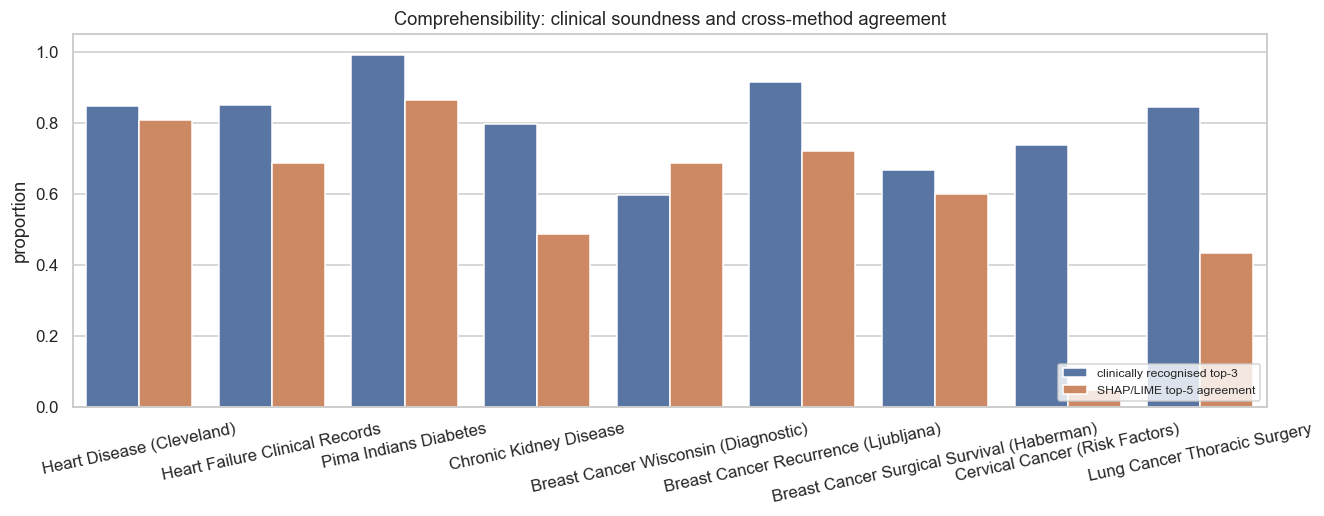

In [10]:
fig, ax = plt.subplots(figsize=(14, 4.4))
frame = pd.DataFrame(
    [
        {
            "dataset": schema.get(slug).title,
            "clinically recognised top-3": c["top3_clinical_hit_rate"],
            "SHAP/LIME top-5 agreement": c["shap_lime_top5_overlap"],
        }
        for slug, c in comprehensibility.items()
    ]
).melt(id_vars="dataset", var_name="metric", value_name="score")
sns.barplot(data=frame, x="dataset", y="score", hue="metric", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel("proportion")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=12)
ax.set_title("Comprehensibility: clinical soundness and cross-method agreement")
ax.legend(fontsize=8, loc="lower right")
plt.savefig(FIGURES / "05_comprehensibility.png")
plt.show()

## 5.8 Summary scorecard

In [11]:
scorecard = pd.DataFrame(
    [
        {
            "dataset": ds.title,
            "model": schema.MODEL_LABELS[BEST[slug]],
            "AUC-ROC": round(evaluation[slug][BEST[slug]]["metrics"]["roc_auc"], 3),
            "F1": round(evaluation[slug][BEST[slug]]["metrics"]["f1"], 3),
            "recall": round(evaluation[slug][BEST[slug]]["metrics"]["recall"], 3),
            "fidelity": fidelity[slug]["fidelity_score"],
            "stability": stability[slug]["mean_neighbour_cosine"],
            "stability gap": stability[slug]["stability_gap"],
            "clinical top-3": comprehensibility[slug]["top3_clinical_hit_rate"],
            "SHAP≈LIME": comprehensibility[slug]["shap_lime_top5_overlap"],
        }
        for slug, ds in schema.DATASETS.items()
    ]
)
display(scorecard.style.format(precision=3).background_gradient(
    subset=["AUC-ROC", "fidelity", "stability", "clinical top-3", "SHAP≈LIME"],
    cmap="Greens"))

,dataset,model,AUC-ROC,F1,recall,fidelity,stability,stability gap,clinical top-3,SHAP≈LIME
0,Heart Disease (Cleveland),Logistic Regression,0.958,0.867,0.929,2.402,0.571,0.598,0.847,0.808
1,Heart Failure Clinical Records,Random Forest,0.789,0.529,0.474,2.441,0.338,0.234,0.850,0.688
2,Pima Indians Diabetes,Random Forest,0.814,0.683,0.759,2.205,0.616,0.602,0.991,0.864
3,Chronic Kidney Disease,Random Forest,1.000,1.000,1.000,3.207,0.664,0.651,0.796,0.488
4,Breast Cancer Wisconsin (Diagnostic),Logistic Regression,0.996,0.964,0.952,3.824,0.761,0.723,0.596,0.688
5,Breast Cancer Recurrence (Ljubljana),Random Forest,0.666,0.519,0.412,1.859,0.515,0.471,0.914,0.720
6,Breast Cancer Surgical Survival (Haberman),Random Forest,0.594,0.200,0.188,1.285,0.708,0.415,0.667,0.600
7,Cervical Cancer (Risk Factors),Logistic Regression,0.631,0.133,0.273,4.430,0.813,0.736,0.738,0.048
8,Lung Cancer Thoracic Surgery,Logistic Regression,0.621,0.276,0.571,2.736,0.645,0.648,0.844,0.432


**What this table licenses us to claim.** For every dataset the SHAP
attributions are measurably more faithful than a random ranking, and clinically
similar patients receive measurably more similar explanations than unrelated
ones. On the six cohorts where the model is actually useful, the features
surfaced to the user are ones the clinical literature already recognises.

### The most important row in this table is a trap

Look at **cervical cancer**. It has the *highest fidelity in the entire project*
(4.43x) and the *highest stability* (0.81). By the explanation-quality metrics
alone it is our best work. It also has an F1 of 0.13 and finds barely a quarter
of the cancers.

Those numbers are not in conflict, and understanding why is the whole point:

* **Fidelity measures loyalty to the model, not to medicine.** A model that
  leans hard on two features will lose a lot of predictive output when you ablate
  those two, which scores as high fidelity. It says the explanation is an honest
  account of the model's reasoning. It says nothing about whether that reasoning
  is any good.
* **Stability measures consistency, and a nearly-constant model is extremely
  consistent.** When a classifier is close to predicting one class for everyone,
  neighbouring patients trivially receive near-identical attributions.

So a faithful, stable, clinically-plausible explanation of a model that misses
three quarters of cancers is exactly what this row is. **The explanation-quality
metrics must never be read without recall beside them** — and had we reported
only fidelity and stability, as a good deal of applied XAI work does, this would
have looked like the strongest result in the project.

### Where the methods disagree

Cervical cancer also has a **SHAP/LIME top-5 overlap of 0.05** — the two methods
essentially never name the same features. With 28 mostly-binary features, 6.4%
positives and a nearly-flat decision surface, LIME's sampled neighbourhood
barely resembles the global structure SHAP averages over. Read against the
0.87 overlap on the diabetes model, this is the clearest signal available that
the cervical explanation is method-dependent, and therefore not something to put
in front of a clinician.

**Breast-cancer diagnosis scores 0.60 on the clinical check** despite 0.996 AUC.
The reference list was fixed in notebook 04 before these scores were computed
and contained the mean and worst variants of the classical malignancy criteria;
the model in fact leans partly on the *variability* (standard-error) columns,
which are not features a cytologist reasons with directly. That is a real
mismatch between what the model uses and what a clinician recognises, and it is
reported rather than corrected by widening the list after the fact.

**What none of this licenses.** These are small, single-centre, retrospective
datasets from the 1970s to the 2010s. The CKD and breast-diagnosis cohorts are
close to separable and should not be read as deployable diagnostics. Three of
the five oncology models are near chance. Nothing here has been validated
prospectively, and the explanations are *faithful to the model* — which, as the
cervical row demonstrates concretely, is a different and much weaker claim than
*clinically correct*.

In [12]:
payload = {
    "generated_by": "notebooks/05_evaluation.ipynb",
    "random_state": data.RANDOM_STATE,
    "best_models": BEST,
    "evaluation": evaluation,
    "explanation_quality": {
        "fidelity": fidelity,
        "stability": stability,
        "comprehensibility": comprehensibility,
    },
    "method_notes": {
        "fidelity": (
            "Top-k highest-|SHAP| features replaced with the training mean "
            "(0 in standardised space), mean |delta probability| compared with "
            "the same number of randomly chosen features over 3 draws. Score is "
            "the ratio of the two averages across k = 1..5."
        ),
        "stability": (
            "Cosine similarity between SHAP attribution vectors of each test "
            "patient and its 5 nearest neighbours in standardised feature space, "
            "against a random-pair baseline."
        ),
        "comprehensibility": (
            "Fraction of each patient's top-3 SHAP features appearing in a "
            "literature-derived risk-factor list fixed in advance, plus mean "
            "top-5 overlap between SHAP and LIME on a 25-patient sample."
        ),
    },
}
(ROOT / "results" / "05_evaluation.json").write_text(json.dumps(payload, indent=2))
scorecard.to_json(ROOT / "results" / "05_scorecard.json", orient="records", indent=2)
thresholds.to_json(ROOT / "results" / "05_heart_failure_thresholds.json",
                   orient="records", indent=2)

print("wrote results/05_evaluation.json, results/05_scorecard.json, "
      "results/05_heart_failure_thresholds.json")
print("\nPhase 1 complete. The API in api/ consumes models/*.pkl and results/*.json.")

wrote results/05_evaluation.json, results/05_scorecard.json, results/05_heart_failure_thresholds.json

Phase 1 complete. The API in api/ consumes models/*.pkl and results/*.json.
